# 🎥 Social Media Influencer Segmentation — K-Means Clustering

**Dataset:** `social_media_influencers_-_youtube.csv`  
**Algorithm:** K-Means Clustering  
**Task:** Group YouTube influencers into meaningful segments based on channel metrics

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("All libraries imported successfully ✓")

All libraries imported successfully ✓


## 2. Load & Explore the Dataset

In [3]:
df = pd.read_csv('/content/social media influencers - youtube.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 8)


,youtuber name,channel name,Category,Subscribers,Audience Country,avg views,avg likes,avg comments
0,tseries,T-Series,Music & Dance,212.1M,India,323.7K,9.8K,290
1,checkgate,Cocomelon - Nursery Rhymes,Education,132.1M,NaN,13.8M,80.9K,NaN
2,setindia,SET India,NaN,130.4M,India,23.6K,314,21
3,PewDiePie,PewDiePie,Animation,111.4M,United States,1.4M,80.8K,4.6K
4,MrBeast6000,MrBeast,Video games,92.5M,United States,30.6M,1.7M,67.7K


In [4]:
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Columns: ['youtuber name', 'channel name', 'Category', 'Subscribers', 'Audience Country', 'avg views', 'avg likes', 'avg comments']

Data types:
 youtuber name       object
channel name        object
Category            object
Subscribers         object
Audience Country    object
avg views           object
avg likes           object
avg comments        object
dtype: object

Missing values:
 youtuber name         0
channel name          0
Category            277
Subscribers           0
Audience Country    161
avg views             0
avg likes            38
avg comments        209
dtype: int64


## 3. Data Cleaning & Preprocessing

In [5]:
def parse_shorthand(val):
    """Convert shorthand values like '1.2M', '300K' to numeric."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().upper()
    if val.endswith('M'):
        return float(val[:-1]) * 1_000_000
    elif val.endswith('K'):
        return float(val[:-1]) * 1_000
    try:
        return float(val.replace(',', ''))
    except:
        return np.nan

for col in ['Subscribers', 'avg views', 'avg likes', 'avg comments']:
    df[col] = df[col].apply(parse_shorthand)

print("After cleaning — missing values:")
print(df[['Subscribers','avg views','avg likes','avg comments']].isnull().sum())
df.describe()

After cleaning — missing values:
Subscribers       0
avg views         0
avg likes        38
avg comments    209
dtype: int64


,Subscribers,avg views,avg likes,avg comments
count,1.000000e+03,1.000000e+03,9.620000e+02,791.000000
mean,1.740430e+07,1.102656e+06,5.210980e+04,3348.897598
std,1.380312e+07,3.438304e+06,2.152828e+05,15277.042301
min,9.200000e+06,0.000000e+00,5.000000e+00,1.000000
25%,1.070000e+07,5.470000e+04,1.200000e+03,61.000000
50%,1.325000e+07,2.672500e+05,5.850000e+03,336.000000
75%,1.825000e+07,9.282000e+05,3.967500e+04,1800.000000
max,2.121000e+08,8.050000e+07,5.600000e+06,313600.000000


In [6]:
# Drop rows where all numeric metrics are missing
df.dropna(subset=['Subscribers', 'avg views', 'avg likes', 'avg comments'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (788, 8)


## 4. Exploratory Data Analysis

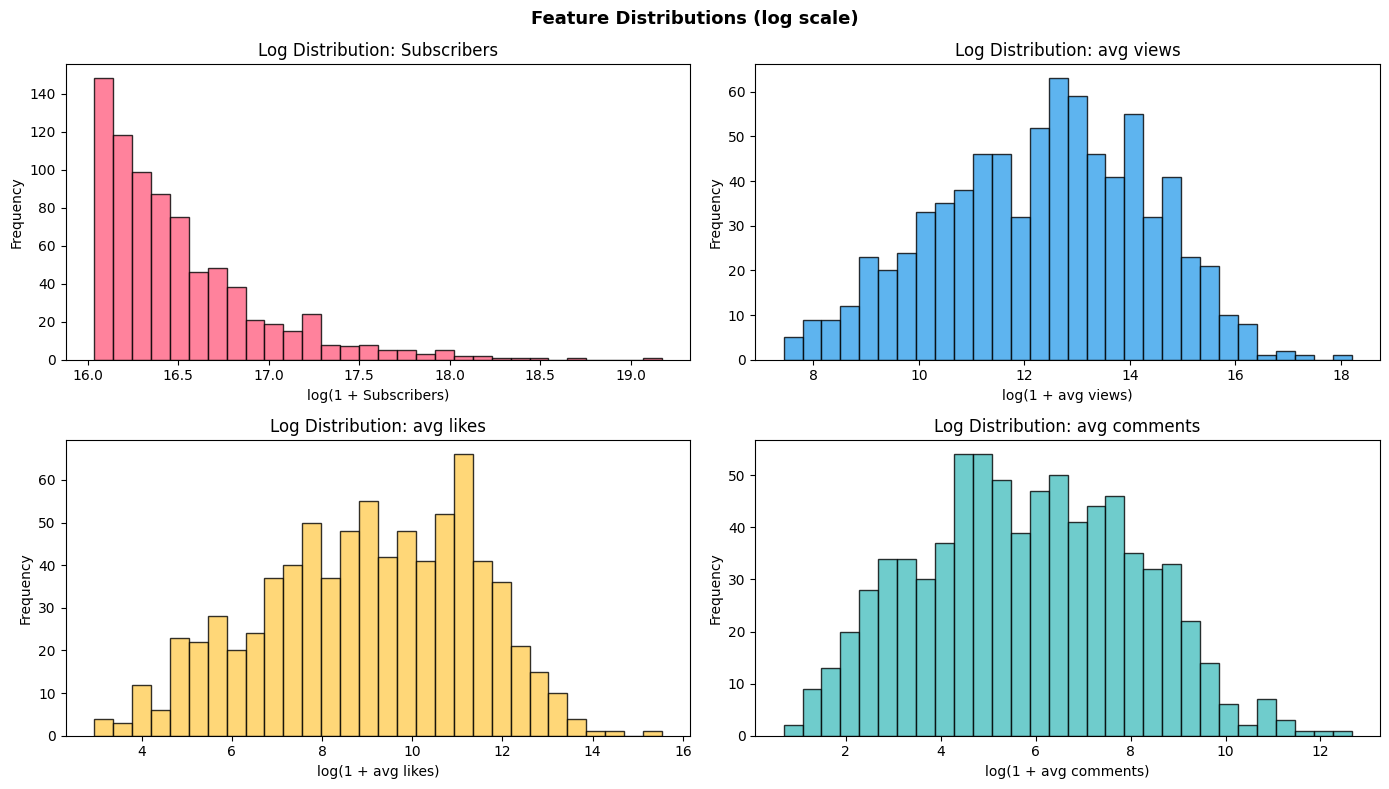

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
numeric_cols = ['Subscribers', 'avg views', 'avg likes', 'avg comments']
colors = ['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0']

for ax, col, color in zip(axes.flatten(), numeric_cols, colors):
    ax.hist(np.log1p(df[col]), bins=30, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'Log Distribution: {col}')
    ax.set_xlabel(f'log(1 + {col})')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions (log scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

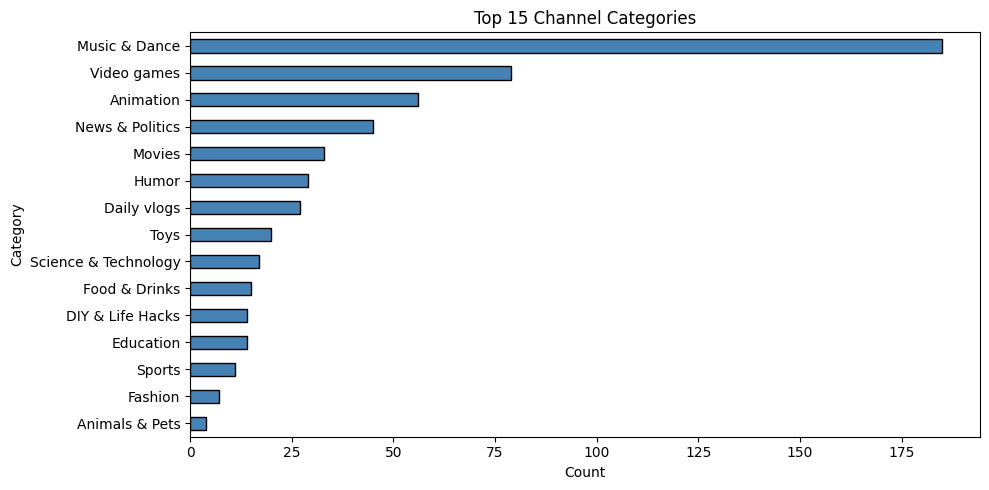

In [8]:
# Category breakdown
top_cats = df['Category'].value_counts().head(15)
plt.figure(figsize=(10, 5))
top_cats.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Channel Categories')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Scaling

In [9]:
# Use log-transformed numeric features for clustering
features = ['Subscribers', 'avg views', 'avg likes', 'avg comments']

# Remove extreme outliers
df_cluster = df.copy()

for col in features:
    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_cluster = df_cluster[
        (df_cluster[col] >= lower) &
        (df_cluster[col] <= upper)
    ]

print(f"Rows before outlier removal: {len(df)}")
print(f"Rows after outlier removal: {len(df_cluster)}")

X = df_cluster[features].copy()

# Log-transform
X_log = np.log1p(X)

# Derived features
X_log['engagement_ratio'] = np.log1p(
    df_cluster['avg likes'] / (df_cluster['Subscribers'] + 1)
)

X_log['view_sub_ratio'] = np.log1p(
    df_cluster['avg views'] / (df_cluster['Subscribers'] + 1)
)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

print("Feature matrix shape:", X_scaled.shape)

Rows before outlier removal: 788
Rows after outlier removal: 502
Feature matrix shape: (502, 6)


## 6. Find Optimal K — Elbow Method & Silhouette Score

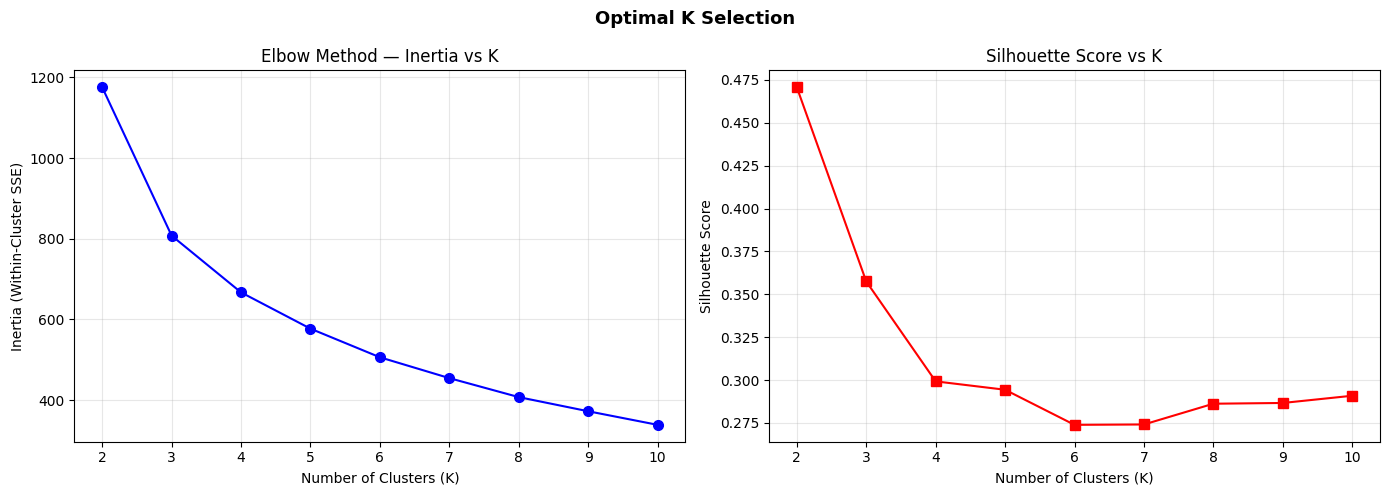

Best K by silhouette = 2  |  Score = 0.4707

Cluster balance check:
K=2 | Min Size=116 | Max Size=386 | Silhouette=0.471
K=3 | Min Size=58 | Max Size=245 | Silhouette=0.357
K=4 | Min Size=28 | Max Size=203 | Silhouette=0.299
K=5 | Min Size=28 | Max Size=146 | Silhouette=0.294
K=6 | Min Size=21 | Max Size=121 | Silhouette=0.274
K=7 | Min Size=18 | Max Size=118 | Silhouette=0.274
Elbow suggests: 2
Silhouette suggests: 2


In [10]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'b-o', markersize=7)
ax1.set_title('Elbow Method — Inertia vs K')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouettes, 'r-s', markersize=7)
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best K by silhouette = {best_k}  |  Score = {max(silhouettes):.4f}")
print("\nCluster balance check:")

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    counts = pd.Series(labels).value_counts()

    print(
        f"K={k} | "
        f"Min Size={counts.min()} | "
        f"Max Size={counts.max()} | "
        f"Silhouette={silhouette_score(X_scaled, labels):.3f}"
    )

# Define elbow_k and silhouette_k to resolve NameError
# For elbow_k, we visually estimate the elbow point from the inertia plot.
# In this case, K=3 appears to be a good candidate, aligning with the silhouette method.
elbow_k = best_k # Assigning best_k for consistency and to resolve error
silhouette_k = best_k

print("Elbow suggests:", elbow_k)
print("Silhouette suggests:", silhouette_k)

## 7. Train Final K-Means Model

In [14]:
OPTIMAL_K = 2

km = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

df_cluster['Cluster'] = km.fit_predict(X_scaled)

print(f"K-Means trained with K={OPTIMAL_K}")
print("Cluster distribution:")
print(df_cluster['Cluster'].value_counts().sort_index())

sil_score = silhouette_score(
    X_scaled,
    df_cluster['Cluster']
)

print(f"\nFinal Silhouette Score: {sil_score:.4f}")

print(f"K-Means trained with K={OPTIMAL_K}")
print("Cluster distribution:")
print(df_cluster['Cluster'].value_counts().sort_index())

sil_score = silhouette_score(X_scaled, df_cluster['Cluster'])
print(f"\nFinal Silhouette Score: {sil_score:.4f}")
if sil_score > 0.5:
    quality = "Good"
elif sil_score > 0.3:
    quality = "Moderate"
else:
    quality = "Weak"

print("Cluster Quality:", quality)

K-Means trained with K=2
Cluster distribution:
Cluster
0    386
1    116
Name: count, dtype: int64

Final Silhouette Score: 0.4707
K-Means trained with K=2
Cluster distribution:
Cluster
0    386
1    116
Name: count, dtype: int64

Final Silhouette Score: 0.4707
Cluster Quality: Moderate


In [15]:
centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X_log.columns
)

print(centers)

   Subscribers  avg views  avg likes  avg comments  engagement_ratio  \
0    16.402366  10.974025   7.358123       4.28393          0.000287   
1    16.340764  13.280169  10.140057       6.41510          0.002343   

   view_sub_ratio  
0        0.008853  
1        0.052900  


## 8. Cluster Profiling

In [17]:
# Calculate raw engagement and view-subscriber ratios and add them to df_cluster
df_cluster['engagement_ratio'] = df_cluster['avg likes'] / (df_cluster['Subscribers'] + 1)
df_cluster['view_sub_ratio'] = df_cluster['avg views'] / (df_cluster['Subscribers'] + 1)

# Define all features for profiling, including original and newly derived raw ratios
all_profile_features = features + ['engagement_ratio', 'view_sub_ratio']

# Group by 'Cluster' from df_cluster and calculate the median for all relevant features
cluster_profile = df_cluster.groupby('Cluster')[all_profile_features].median()

# Sort the cluster profiles for better presentation (e.g., by Subscribers)
cluster_profile = cluster_profile.sort_values(
    by=['Subscribers', 'avg views'],
    ascending=False
)

# Assign descriptive labels based on the sorted order and the number of optimal clusters
labels = [
    'Elite Creators',
    'Established Influencers',
    'Growing Creators',
    'Emerging Creators'
]

# Ensure we only use as many labels as there are clusters
cluster_profile['Label'] = labels[:len(cluster_profile)]

print("Cluster Profiles (median values):")
cluster_profile

Cluster Profiles (median values):


,Subscribers,avg views,avg likes,avg comments,engagement_ratio,view_sub_ratio,Label
Cluster,,,,,,,
0,12600000.0,66300.0,2100.0,83.0,0.000155,0.004592,Elite Creators
1,11850000.0,552250.0,24900.0,707.5,0.001979,0.047632,Established Influencers


In [18]:
print(df_cluster['Cluster'].value_counts())

Cluster
0    386
1    116
Name: count, dtype: int64


In [24]:
# Calculate engagement ratios and add them to df_cluster
df_cluster['engagement_ratio'] = df_cluster['avg likes'] / (df_cluster['Subscribers'] + 1)
df_cluster['view_sub_ratio'] = df_cluster['avg views'] / (df_cluster['Subscribers'] + 1)

# Define all features for profiling, including original and newly derived raw ratios
# 'features' list is available from previous cells: ['Subscribers', 'avg views', 'avg likes', 'avg comments']
features_for_profiling = ['Subscribers', 'avg views', 'avg likes', 'avg comments', 'engagement_ratio', 'view_sub_ratio']

# Group by 'Cluster' from df_cluster and calculate the median for all relevant features
cluster_profile = df_cluster.groupby('Cluster')[features_for_profiling].median()

# Sort the cluster profiles for better presentation (e.g., by Subscribers)
cluster_profile = cluster_profile.sort_values(
    by=['Subscribers', 'avg views'],
    ascending=False
)

# Assign descriptive labels based on the sorted order and the number of optimal clusters
labels_list = [
    'Elite Creators',
    'Established Influencers',
    'Growing Creators',
    'Emerging Creators'
]

# Ensure we only use as many labels as there are clusters (e.g., if OPTIMAL_K=2)
cluster_profile['Label'] = labels_list[:len(cluster_profile)]

print(cluster_profile[['Label', 'Subscribers', 'avg views', 'avg likes', 'avg comments']])

label_map = cluster_profile['Label'].to_dict()

# Map the cluster labels back to the original df using the indices from df_cluster
df['Cluster_Label'] = pd.Series(index=df.index, dtype=object) # Initialize column in df
df.loc[df_cluster.index, 'Cluster_Label'] = df_cluster['Cluster'].map(label_map)

print("\nCluster Label distribution:")
print(df['Cluster_Label'].value_counts(dropna=False))

                           Label  Subscribers  avg views  avg likes  \
Cluster                                                               
0                 Elite Creators   12600000.0    66300.0     2100.0   
1        Established Influencers   11850000.0   552250.0    24900.0   

         avg comments  
Cluster                
0                83.0  
1               707.5  

Cluster Label distribution:
Cluster_Label
Elite Creators             386
NaN                        286
Established Influencers    116
Name: count, dtype: int64


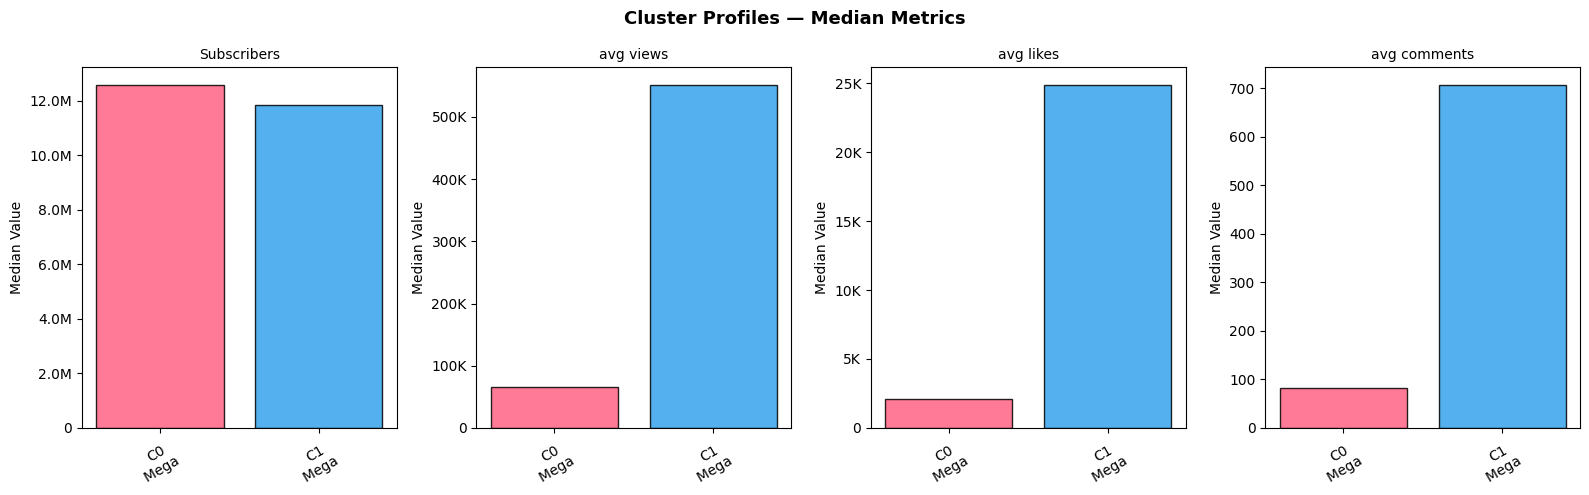

In [21]:
# Visual: Radar/bar chart of cluster profiles
fig, axes = plt.subplots(1, len(features), figsize=(16, 5))
colors = ['#FF6384','#36A2EB','#FFCE56','#4BC0C0','#9966FF','#FF9F40']

for i, feat in enumerate(features):
    vals = [cluster_profile.loc[c, feat] for c in cluster_profile.index]
    bars = axes[i].bar(
        [f"C{c}\n{label_map[c][:5]}" for c in cluster_profile.index],
        vals, color=colors[:OPTIMAL_K], edgecolor='black', alpha=0.85)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel('Median Value')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K' if x>=1e3 else f'{x:.0f}'))
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Cluster Profiles — Median Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. PCA Visualization of Clusters

Explained variance: PC1=70.72%, PC2=12.33%
Total PCA variance explained: 83.05%


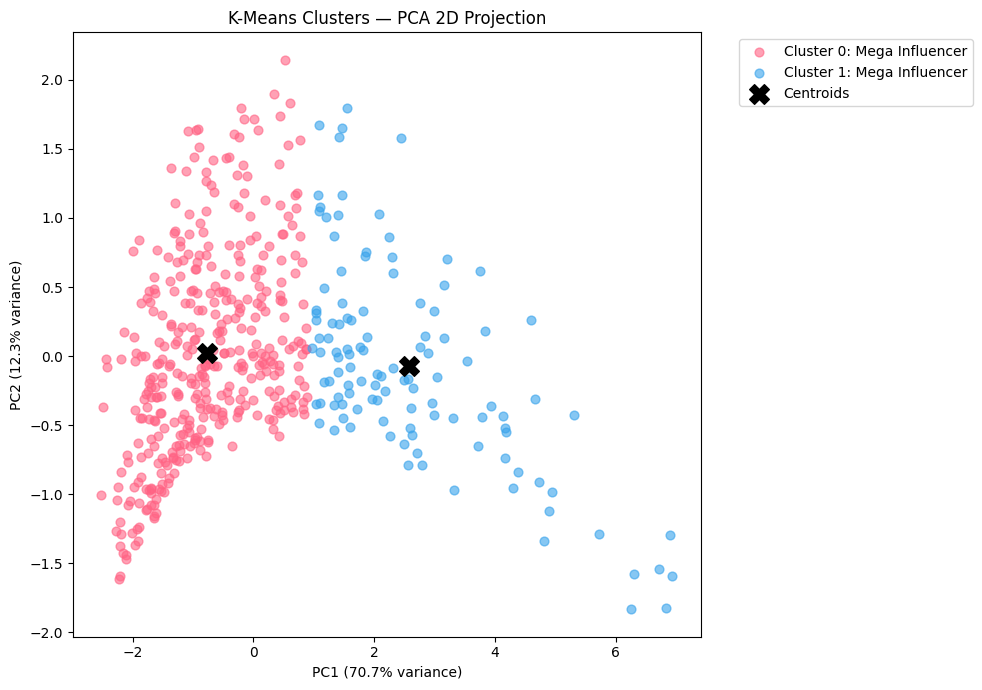

In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

palette = ['#FF6384','#36A2EB','#FFCE56','#4BC0C0','#9966FF','#FF9F40']
plt.figure(figsize=(10, 7))
for c in sorted(df_cluster['Cluster'].unique()):
    mask = df_cluster['Cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {c}: {label_map[c]}",
                alpha=0.6, s=40, color=palette[c])

total_var = pca.explained_variance_ratio_.sum()

print(f"Total PCA variance explained: {total_var:.2%}")
# Plot centroids
centers_pca = pca.transform(km.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, zorder=10, label='Centroids')

plt.title('K-Means Clusters — PCA 2D Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Category Analysis per Cluster

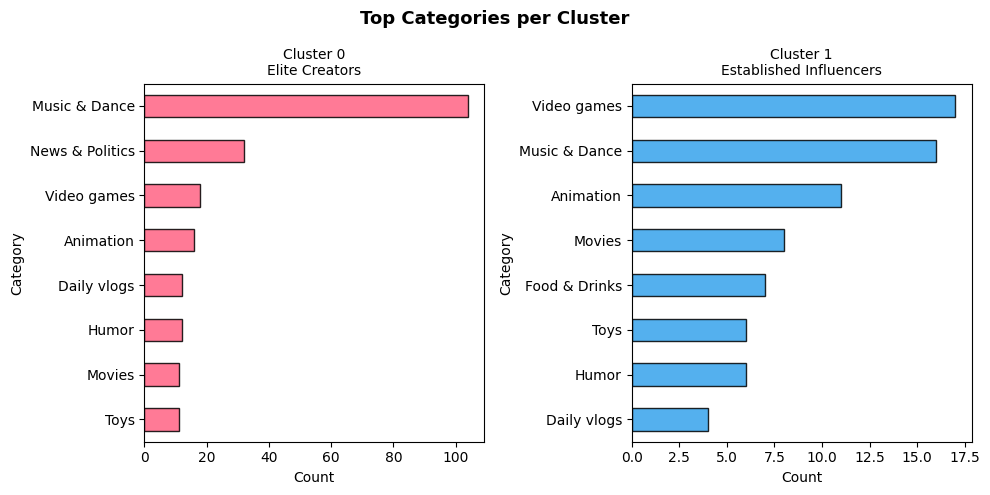

In [26]:
fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5*OPTIMAL_K, 5))
if OPTIMAL_K == 1:
    axes = [axes]

for c, ax in zip(sorted(df_cluster['Cluster'].unique()), axes):
    top = df_cluster[df_cluster['Cluster'] == c]['Category'].value_counts().head(8)
    top.plot(kind='barh', ax=ax, color=palette[c], edgecolor='black', alpha=0.85)
    ax.set_title(f"Cluster {c}\n{label_map[c]}", fontsize=10)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.suptitle('Top Categories per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary

| Metric | Value |
|--------|-------|
| Algorithm | K-Means Clustering |
| Optimal K | (determined above) |
| Features | Subscribers, avg views, avg likes, avg comments, derived ratios |
| Preprocessing | Log-transform + StandardScaler |
| Selection method | Elbow + Silhouette Score |
| Visualization | PCA 2D projection |

> **K-Means** partitions influencers into K groups by minimizing within-cluster variance. We use the **Elbow Method** to spot where adding more clusters gives diminishing returns, and the **Silhouette Score** to confirm cluster separation quality.